# Compare training plots

Set the run folders in the next cell. Each run folder should contain matching PNGs inside `training_plots` and, if present, `enzyme_explorer_validation`.

Then run the notebook to discover all shared PNGs and display each plot side by side across runs.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Markdown, display

runs = [
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_class_prepend_first_cyclization_run_10",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_class_first_cyclization_run_30",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_class_mini_first_cyclization_run_02",
]

plot_subdirs = ["training_plots", "enzyme_explorer_validation"]
figure_height = 4
max_title_length = 60

# training_plots

Found **9** shared plot files.

## `NLL_loss.png`

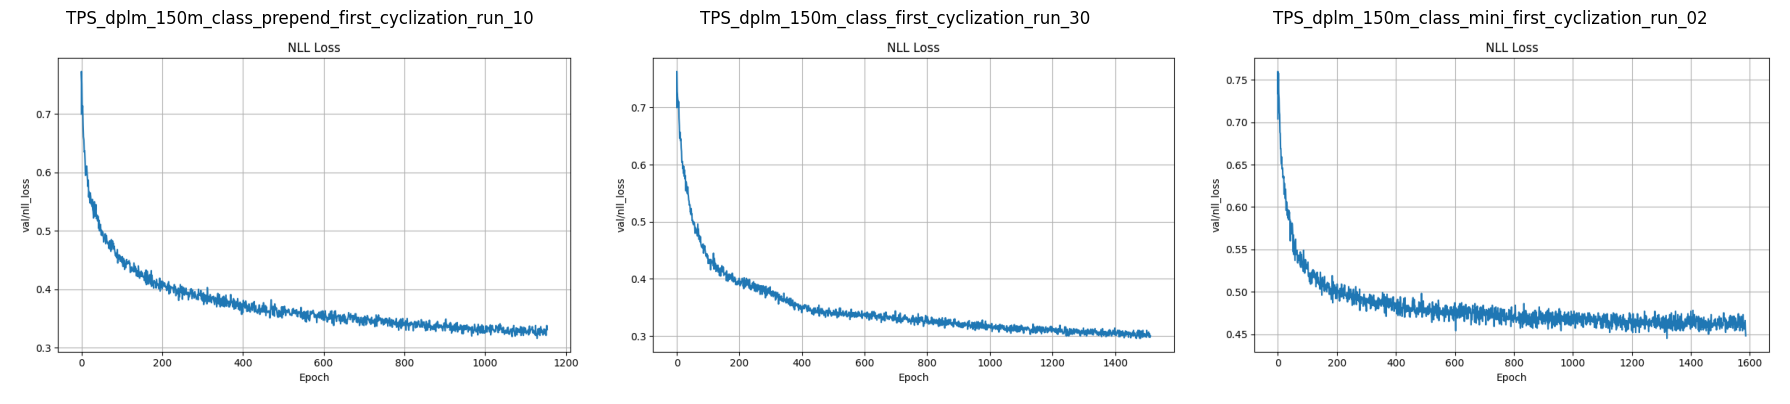

## `NLL_loss_global_steps.png`

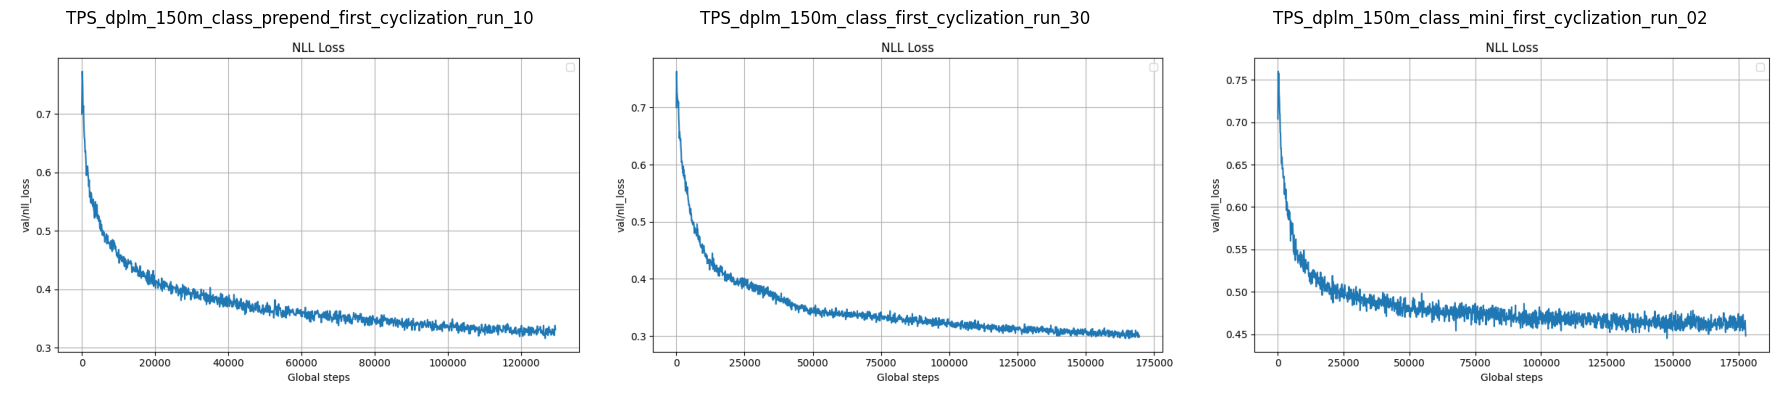

## `accuracy_global_steps.png`

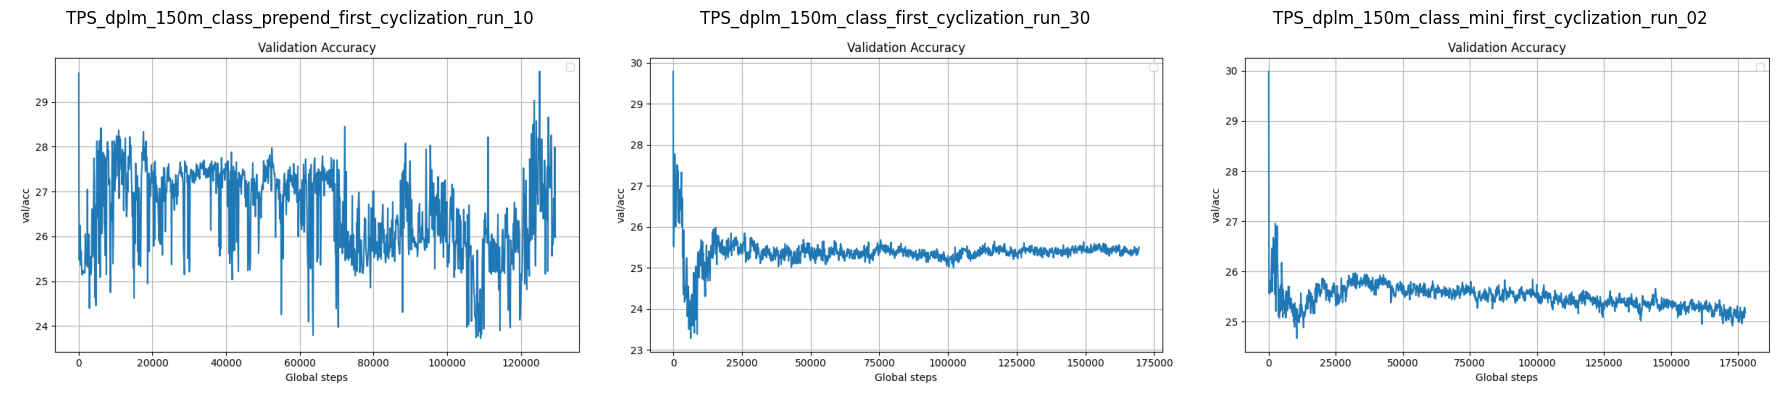

## `loss.png`

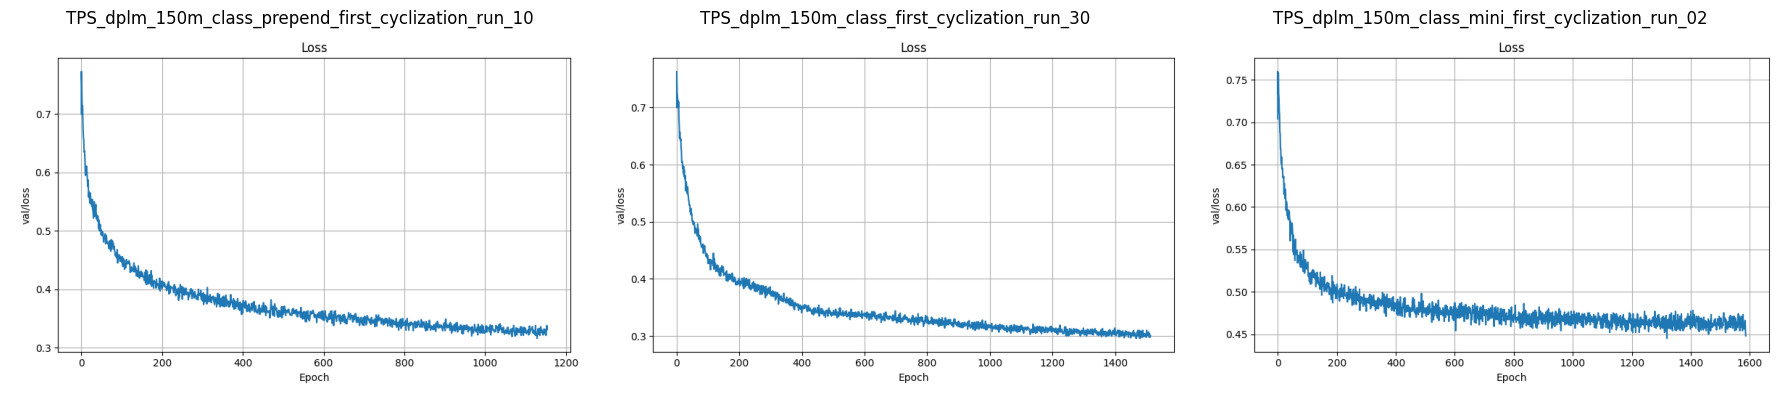

## `loss_global_steps.png`

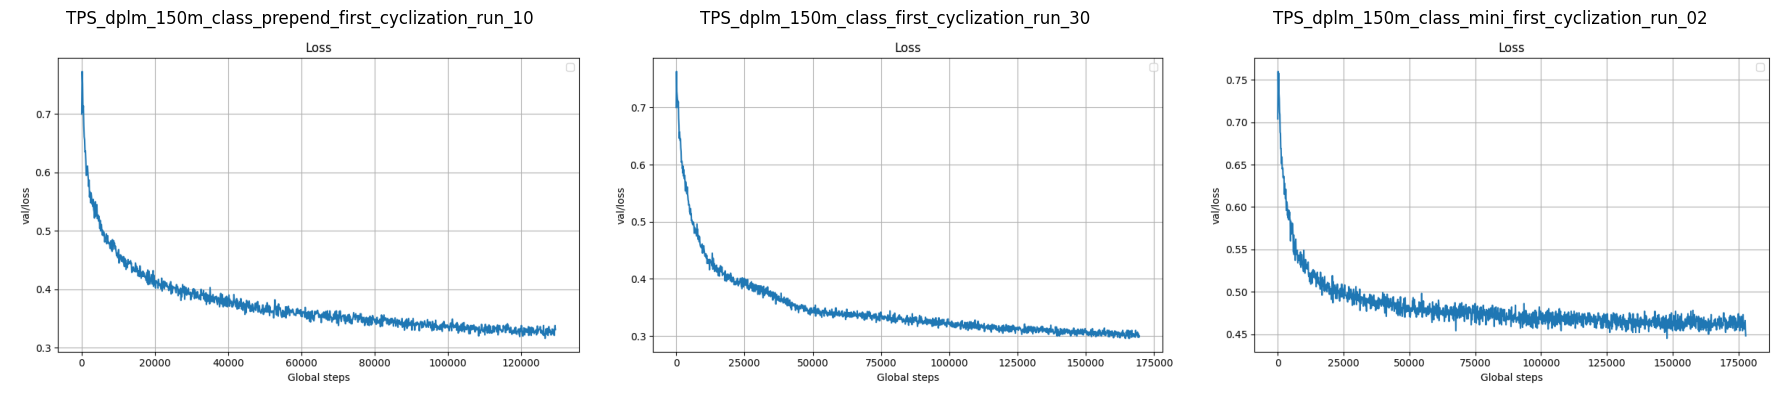

## `perplexity.png`

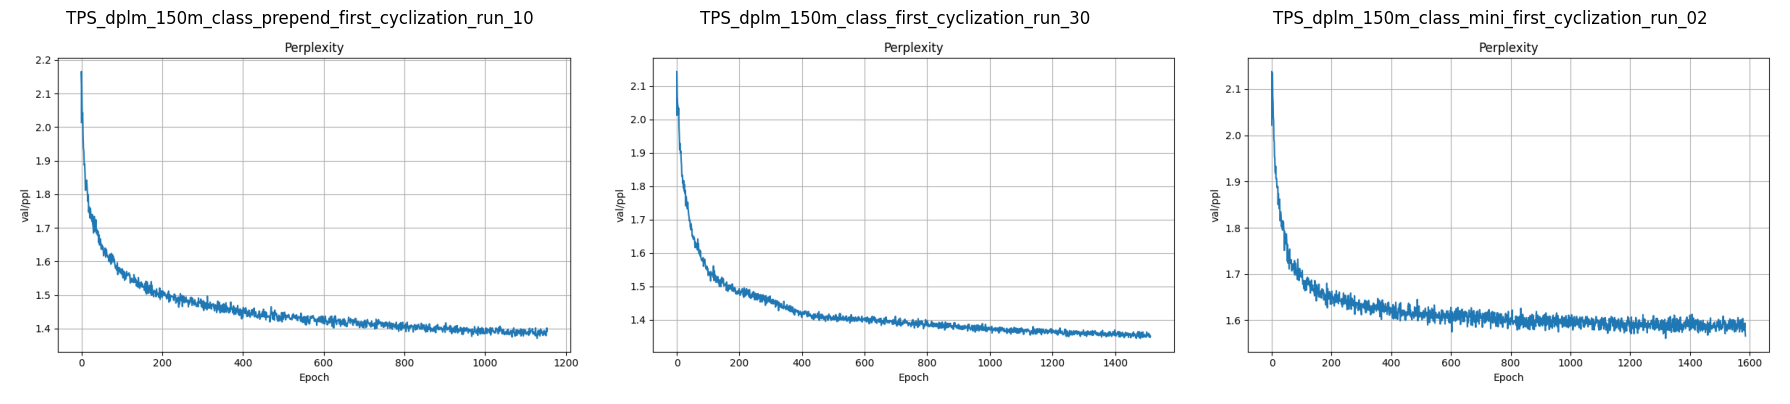

## `perplexity_best.png`

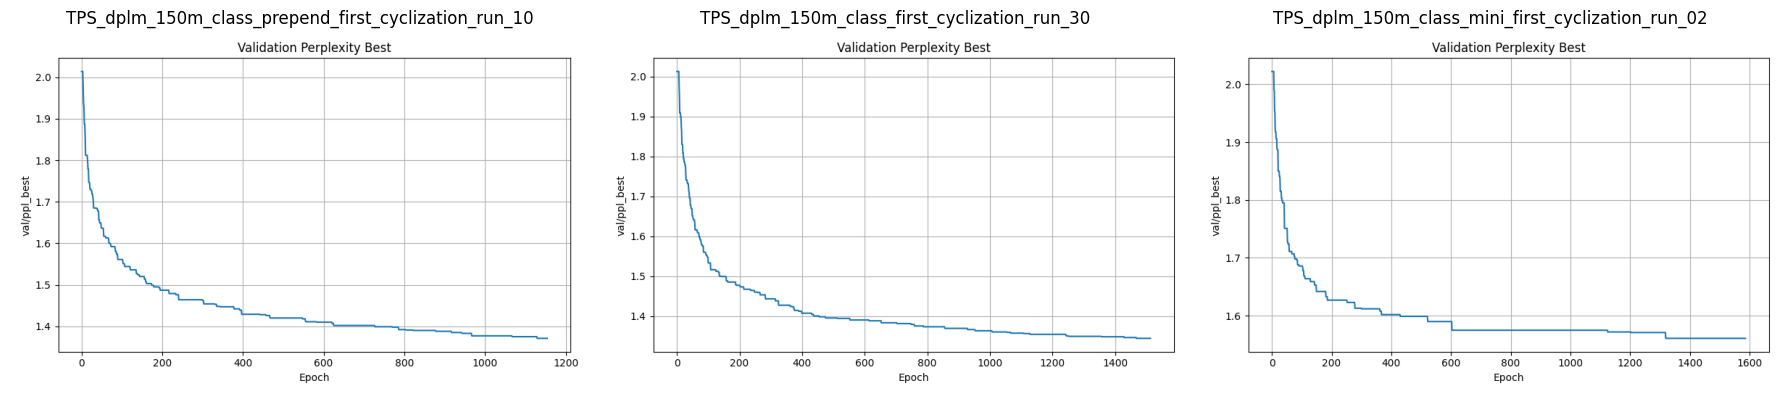

## `perplexity_best_global_steps.png`

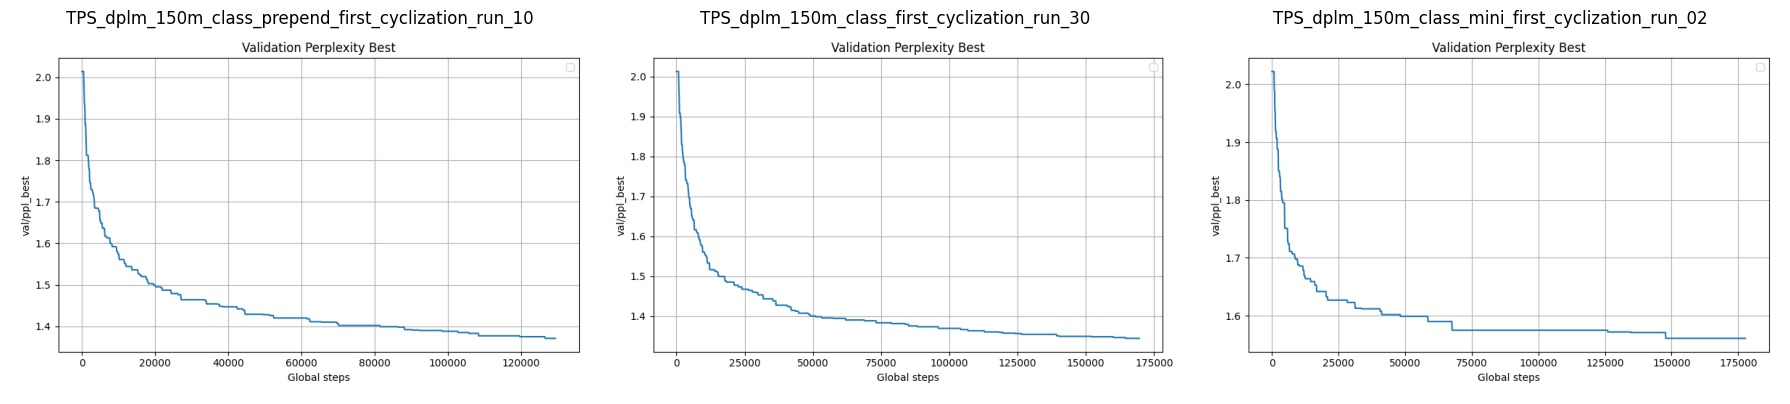

## `perplexity_global_steps.png`

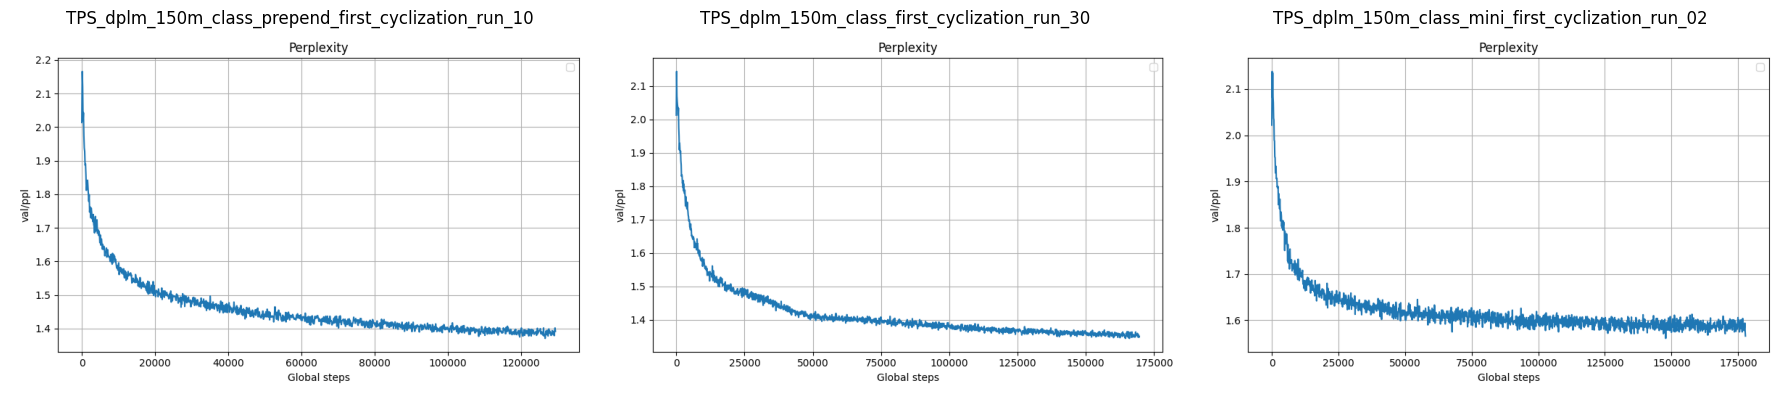

# enzyme_explorer_validation

Found **3** shared plot files.

## `isTPS_by_epoch_boxplot.png`

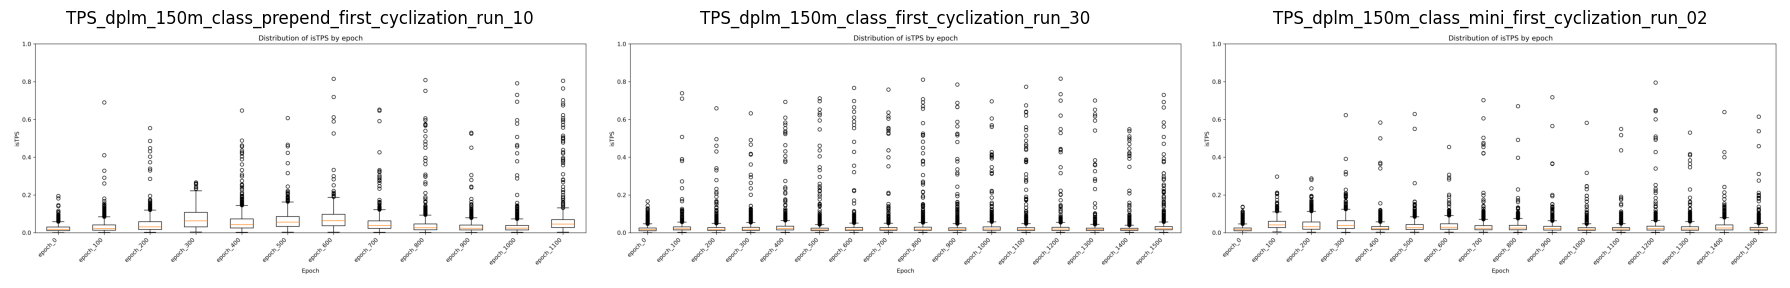

## `isTPS_by_epoch_counts.png`

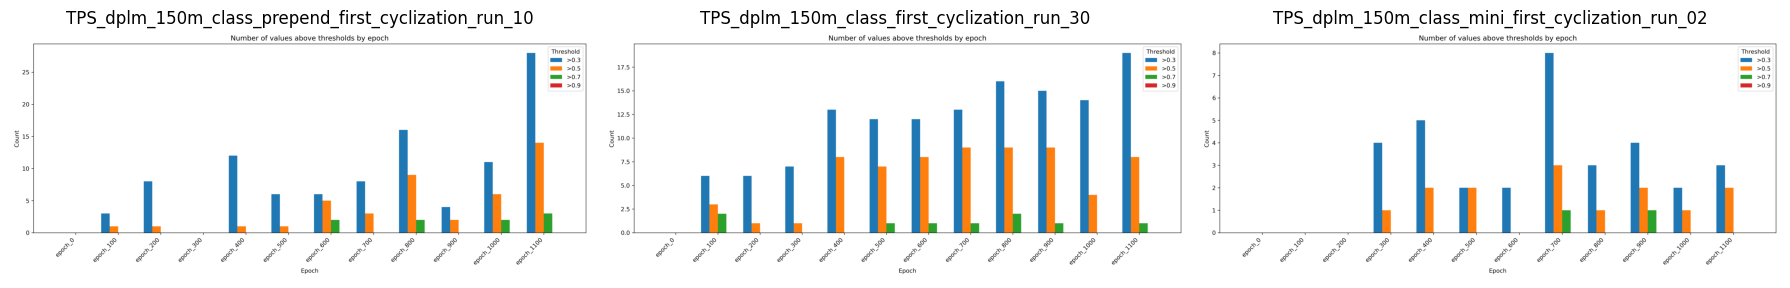

## `isTPS_by_epoch_violin.png`

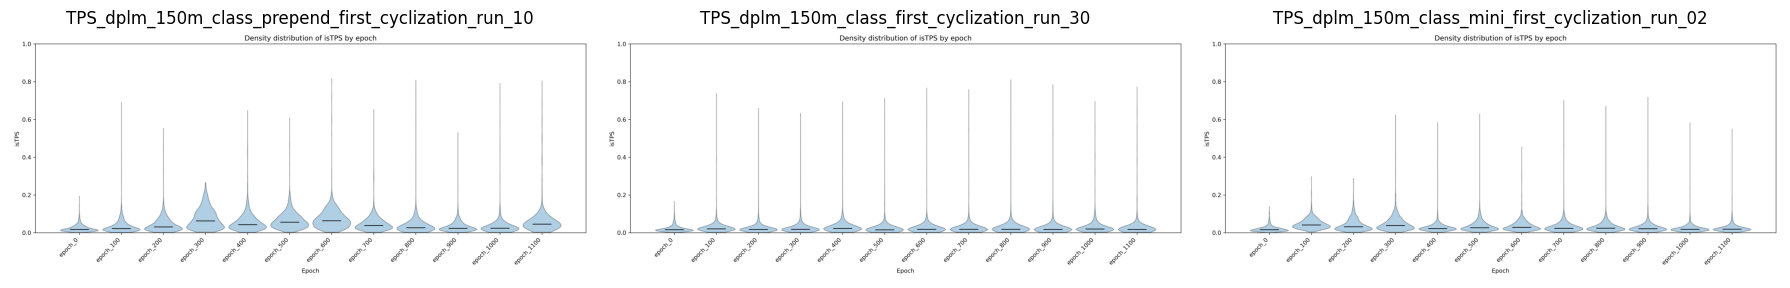

In [4]:
def collect_plot_paths(run_path, plot_subdir):
    plot_root = Path(run_path).expanduser() / plot_subdir
    if not plot_root.exists():
        raise FileNotFoundError(f"Plot directory not found: {plot_root}")
    return sorted(path.relative_to(plot_root) for path in plot_root.rglob("*.png"))


def truncate_title(text, limit=60):
    return text if len(text) <= limit else text[: limit - 3] + "..."


def normalize_runs(runs):
    if not runs:
        raise ValueError("Define at least one run path in `runs`.")

    normalized_runs = []
    for run in runs:
        if isinstance(run, dict):
            if "path" not in run:
                raise KeyError("Each run dict must define a `path`.")
            run_path = Path(run["path"]).expanduser()
            label = run.get("label", run_path.name)
        else:
            run_path = Path(run).expanduser()
            label = run_path.name

        normalized_runs.append({"label": label, "path": run_path})

    return normalized_runs


def show_plot_group(normalized_runs, plot_subdir, figure_height=4, max_title_length=60):
    per_run_paths = []
    for run in normalized_runs:
        relative_paths = collect_plot_paths(run["path"], plot_subdir)
        per_run_paths.append(
            {
                "label": run["label"],
                "plot_root": run["path"] / plot_subdir,
                "relative_paths": relative_paths,
            }
        )

    common_relative_paths = set(per_run_paths[0]["relative_paths"])
    for run in per_run_paths[1:]:
        common_relative_paths &= set(run["relative_paths"])
    common_relative_paths = sorted(common_relative_paths)

    if not common_relative_paths:
        display(Markdown(f"## {plot_subdir}"))
        display(Markdown("No shared PNG files were found across the provided runs."))
        return

    display(Markdown(f"# {plot_subdir}"))
    display(Markdown(f"Found **{len(common_relative_paths)}** shared plot files."))

    for relative_path in common_relative_paths:
        display(Markdown(f"## `{relative_path.as_posix()}`"))

        fig, axes = plt.subplots(
            1,
            len(per_run_paths),
            figsize=(6 * len(per_run_paths), figure_height),
            squeeze=False,
        )
        axes = axes[0]

        for ax, run in zip(axes, per_run_paths):
            image_path = run["plot_root"] / relative_path
            image = mpimg.imread(image_path)
            ax.imshow(image)
            ax.axis("off")
            ax.set_title(truncate_title(run["label"], max_title_length))

        fig.tight_layout()
        plt.show()


def show_plot_comparisons(runs, plot_subdirs, figure_height=4, max_title_length=60):
    normalized_runs = normalize_runs(runs)

    for plot_subdir in plot_subdirs:
        show_plot_group(
            normalized_runs,
            plot_subdir,
            figure_height=figure_height,
            max_title_length=max_title_length,
        )


show_plot_comparisons(
    runs,
    plot_subdirs=plot_subdirs,
    figure_height=figure_height,
    max_title_length=max_title_length,
)